In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# concept_gts_f's 6 dims, in order (see preprocessing.ipynb: Fear+Authority merged,
# plus Urgency/Curiosity/Neutral/Reply/Open attachment)
with open('../metadata/emails/concept_names_filtered.txt') as f:
    NEW_CONCEPT_NAMES = f.read().splitlines()

data_path = '../data/train.parquet'
train = pd.read_parquet(data_path)
train_class = train[train['label'].isin([0, 1])]

data_path = '../data/val.parquet'
val = pd.read_parquet(data_path)
val_class = val[val['label'].isin([0, 1])]

data_path = '../data/user_study_data.parquet'
test = pd.read_parquet(data_path)
test_class = test[test['label'].isin([0, 1])]

X_train = np.stack(train['embedding'].values)
y_train = np.stack(train['concept_gts_f'].values)[:,:]


# 3. Initialize the Multi-Output Linear Model
# MultiOutputClassifier fits one regressor per concept/label
model = MultiOutputClassifier(
    #LogisticRegression(max_iter=1000, solver='lbfgs')
    #SVC(kernel='rbf', C=1.0, class_weight='balanced') #0.92
    #SVC(kernel='rbf', C=1000.0, class_weight='balanced') #0.90
    SVC(kernel='linear', C=1.0) #0.87 
    #SVC(kernel='linear', C=0.01) #0.80
)

# 4. Train the model
model.fit(X_train, y_train)

# 5. Evaluate
X_val = np.stack(val['embedding'].values)
concept_preds = model.predict(X_val)
y_val = np.stack(val['concept_gts_f'].values)[:,:]
print(classification_report(y_val, concept_preds, target_names=NEW_CONCEPT_NAMES))

X_test = np.stack(test['embedding'].values)
concept_preds = model.predict(X_test)
y_test = np.stack(test['concept_gts_f'].values)[:,:]
print(classification_report(y_test, concept_preds, target_names=NEW_CONCEPT_NAMES))

                 precision    recall  f1-score   support

 Fear+Authority       0.92      0.91      0.91       107
        Urgency       0.89      0.85      0.87       149
      Curiosity       0.82      0.79      0.80       123
        Neutral       0.84      0.80      0.82        76
          Reply       0.83      0.28      0.42        18
Open attachment       1.00      0.08      0.14        13

      micro avg       0.87      0.80      0.83       486
      macro avg       0.88      0.62      0.66       486
   weighted avg       0.87      0.80      0.82       486
    samples avg       0.87      0.83      0.83       486

                 precision    recall  f1-score   support

 Fear+Authority       0.89      0.90      0.89       510
        Urgency       0.91      0.94      0.92       564
      Curiosity       0.69      0.40      0.51       275
        Neutral       0.92      0.80      0.85       399
          Reply       0.89      0.22      0.35        37
Open attachment       0.67 

/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[[0 0 0 1 0 0]
 [1 1 0 0 0 0]
 [1 1 0 0 0 0]
 ...
 [1 1 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]]
[[-1 -1 -1  1 -1 -1]
 [ 1  1 -1 -1 -1 -1]
 [ 1  1 -1 -1 -1 -1]
 ...
 [ 1  1 -1 -1 -1 -1]
 [-1 -1 -1  1 -1 -1]
 [-1 -1 -1  1 -1 -1]]
-----------------------------------------------------
GT concepts


[-1.89604544 -1.47520773 -0.03120011  0.47345462  0.86965197 -1.52698886]


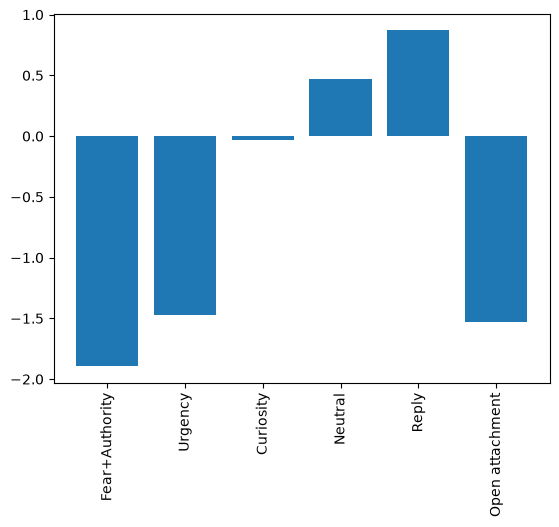

Fear+Authority has weight -1.90 in predicting VALID EMAIL (class 1)
Urgency has weight -1.48 in predicting VALID EMAIL (class 1)
Curiosity has weight -0.03 in predicting VALID EMAIL (class 1)
Neutral has weight 0.47 in predicting VALID EMAIL (class 1)
Reply has weight 0.87 in predicting VALID EMAIL (class 1)
Open attachment has weight -1.53 in predicting VALID EMAIL (class 1)
-----------------[Train set]---------------------
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       366
           1       0.93      0.95      0.94       185

    accuracy                           0.96       551
   macro avg       0.95      0.96      0.95       551
weighted avg       0.96      0.96      0.96       551

-------------------------------------------------
-----------------[Val set]---------------------
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        92
           1       0.94      0.96    

/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


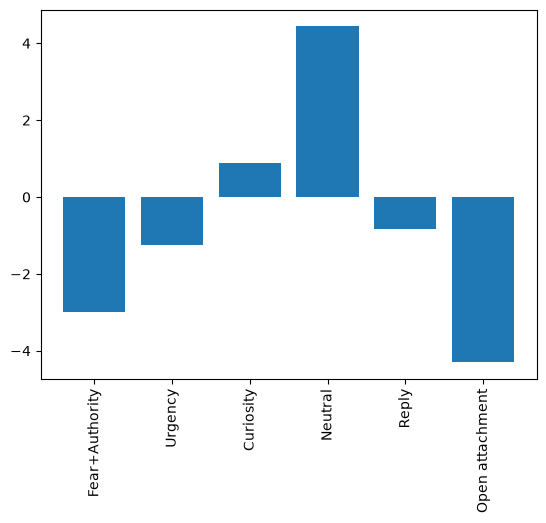

Fear+Authority has weight -2.99 in predicting VALID EMAIL (class 1)
Urgency has weight -1.24 in predicting VALID EMAIL (class 1)
Curiosity has weight 0.88 in predicting VALID EMAIL (class 1)
Neutral has weight 4.44 in predicting VALID EMAIL (class 1)
Reply has weight -0.84 in predicting VALID EMAIL (class 1)
Open attachment has weight -4.31 in predicting VALID EMAIL (class 1)


              precision    recall  f1-score   support

           0       0.91      0.92      0.91       500
           1       0.92      0.91      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [2]:
# From GT concepts
y_train = np.stack(train_class['label'].values)
concept_gts = np.stack(train_class['concept_gts_f'].values)[:,:]
print(concept_gts)
concept_gts = 2*concept_gts-1
print(concept_gts)

final_layer = LogisticRegression(max_iter=1000, C=1, solver='lbfgs', fit_intercept=False, penalty=None, class_weight='balanced')
#final_layer = SVC(kernel='linear', C=100.0, class_weight='balanced', probability=True)
#final_layer = LinearSVC(C=1, class_weight='balanced', fit_intercept=True)

print("-----------------------------------------------------")
print("GT concepts")
final_layer.fit(concept_gts, y_train)

# 5. Evaluate
test_concepts = np.stack(test_class['concept_gts_f'].values)[:,:]
test_concepts = 2*test_concepts-1
train_concepts = np.stack(train_class['concept_gts_f'].values)[:,:]
train_concepts = 2*train_concepts-1
val_concepts = np.stack(val_class['concept_gts_f'].values)[:,:]
val_concepts = 2*val_concepts-1

test_labels = np.stack(test_class['label'].values)
train_labels = np.stack(train_class['label'].values)
val_labels = np.stack(val_class['label'].values)

y_pred_test = final_layer.predict(test_concepts)
y_pred_train = final_layer.predict(train_concepts)
y_pred_val = final_layer.predict(val_concepts)
weights = final_layer.coef_[0]
import matplotlib.pyplot as plt 

print(weights)
plt.bar(range(len(weights)), weights)
plt.xticks(range(len(weights)), NEW_CONCEPT_NAMES, rotation=90)
plt.show()
for i,w in enumerate(weights):
    print(f"{NEW_CONCEPT_NAMES[i]} has weight {w:.2f} in predicting VALID EMAIL (class 1)")

print('-----------------[Train set]---------------------')
print(classification_report(train_labels, y_pred_train))
print('-------------------------------------------------')
print('-----------------[Val set]---------------------')
print(classification_report(val_labels, y_pred_val))
print('-------------------------------------------------')
print('-----------------[Test set]---------------------')
print(classification_report(test_labels, y_pred_test))
print('-------------------------------------------------')
# From learned concepts
y_train = np.stack(train_class['label'].values)
#concept_gts = np.stack(train_class['concept_gts'].values)

final_layer_seq = LogisticRegression(max_iter=1000, solver='lbfgs', fit_intercept=False, penalty=None)

print("-----------------------------------------------------")
print("Learned concepts")

concept_preds = model.predict(np.stack(train_class['embedding'].values))
final_layer_seq.fit(concept_preds, y_train)

# 5. Evaluate
#test_concept_preds = model.predict(np.stack(test_class['embedding'].values))
weights = final_layer_seq.coef_[0]
import matplotlib.pyplot as plt 

plt.bar(range(len(weights)), weights)
plt.xticks(range(len(weights)), NEW_CONCEPT_NAMES, rotation=90)
plt.show()

for i,w in enumerate(weights):
    print(f"{NEW_CONCEPT_NAMES[i]} has weight {w:.2f} in predicting VALID EMAIL (class 1)")
test_concept_preds = model.predict(np.stack(test_class['embedding'].values))

logits = [estimator.decision_function(X_test) for estimator in model.estimators_]
logits_array = np.column_stack(logits)
y_pred = final_layer_seq.predict(logits_array)
test_labels = np.stack(test_class['label'].values)
print(classification_report(test_labels, y_pred))

In [3]:
import numpy as np
# Use the independent final layer 

# class predictor
# y_train = np.stack(train_class['label'].values)
# concept_gts = np.stack(train_class['concept_gts'].values)[:,FILTERED_CONCEPTS]

# final_layer = LogisticRegression(max_iter=1000, solver='lbfgs', fit_intercept=False, penalty=None)
# final_layer.fit(concept_gts, y_train)

# Get concept predictions
test_concept_preds = model.predict(np.stack(test_class['embedding'].values))

logits = [estimator.decision_function(X_test) for estimator in model.estimators_]
logits_array = np.column_stack(logits)
mmin = np.min(logits_array, axis=0)
mmax = np.max(logits_array, axis=0)
col_max = np.max(abs(logits_array), axis=0, keepdims=True)
print(col_max)
logits_norm = 2*(logits_array - mmin)/(mmax-mmin)-1
#logits_norm = logits_array/col_max
#logits_norm = 2*np.random.random(logits_norm.shape)-1
print(np.min(logits_norm, axis=0), np.max(logits_norm, axis=0))
print(logits_norm.shape)
transformed_probs = np.tanh(logits_array)
#print(transformed_probs)
#asd
#print(logits_array)
logits_array = transformed_probs

# Get class prediction
y_pred = final_layer.predict(logits_array)
test_labels = np.stack(test_class['label'].values)
print(classification_report(test_labels, y_pred))
correct = (test_labels == y_pred)
print('accuracy', correct.sum()/1000)

# Get indices where prediction is incorrect
incorrect_mask = y_pred != test_labels

# Split by true label
false_positives = np.where((y_pred == 1) & (test_labels == 0))[0]  # predicted positive, actually negative
false_negatives = np.where((y_pred == 0) & (test_labels == 1))[0]  # predicted negative, actually positive

#print(f"False Positives (predicted 1, true 0): {len(false_positives)}")
#print(false_positives)

#print(f"\nFalse Negatives (predicted 0, true 1): {len(false_negatives)}")
#print(false_negatives)

weights = final_layer.coef_[0]
weights_seq = final_layer_seq.coef_[0]
print(weights)
#print('bias',final_layer.intercept_)
print(weights_seq)

[[2.94655674 3.38611885 2.93970267 3.09310666 2.33825147 2.70918389]]
[-1. -1. -1. -1. -1. -1.] [1. 1. 1. 1. 1. 1.]
(1000, 6)
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       500
           1       0.95      0.89      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000

accuracy 0.92
[-1.89604544 -1.47520773 -0.03120011  0.47345462  0.86965197 -1.52698886]
[-2.9903803  -1.2373622   0.8792877   4.43727398 -0.83669666 -4.30510175]


In [4]:
fp_df = test_class.iloc[false_positives]
fn_df = test_class.iloc[false_negatives]
fp_df.drop(columns=['embedding']).to_csv('../data/false_positives.csv', index=False)
fn_df.drop(columns=['embedding']).to_csv('../data/false_negatives.csv', index=False)

print(fp_df['Body'].iloc[0])

print(fn_df['Body'].iloc[0])

Anonymous mentioned you on an issue Project roadmap / RM-48526 Audit [link] John 9:23 AM EDT @Anonymous Please review. View issue [link] You have free access to Jira Work Management, our project management tool for marketing, operations, and other business teams. Create a project Manage notifications • Give feedback • Privacy policy
Project Invite You have been invited to an Overleaf project. Project: master_thesis Shared by: anonymous@ifi.uio.no view project https://www.overleaf.com/project/65db31e01a850/invite/token/a67a0e68cfa900170414b250e997b


In [5]:
cols = [
    'No.',
    'Original email No.',
    'Subject',
    'Body',
    'Sender',
    'URL(s)',
    'File',
    'Type',
    'Created by',
    'Source',
    'Year',
    'label',
    'concept_gts_f'
]

df_copy = test[cols].copy()

# add concepts

import numpy as np
from pathlib import Path

# Assuming your array is called `arr`
col_names = ['c1_pred', 'c2_pred', 'c3_pred', 'c4_pred', 'c5_pred', 'c6_pred']  # rename as needed

for i, col_name in enumerate(col_names):
    df_copy[col_name] = logits_array[:, i]
    pos_avg = df_copy[col_name][df_copy[col_name] > 0].mean()
    neg_avg = df_copy[col_name][df_copy[col_name] < 0].mean()
    print(f"{col_name}: pos_avg={pos_avg:.4f}, neg_avg={neg_avg:.4f}")

# Assuming your array is called `arr`
col_names = ['c1_gt', 'c2_gt', 'c3_gt', 'c4_gt', 'c5_gt', 'c6_gt']  # rename as needed

for i, col_name in enumerate(col_names):
    df_copy[col_name] = y_test[:, i]

df_copy['task_pred'] = y_pred

df_copy['task_gt'] = test_labels

output_path = Path('../data/user_study/emails_user_study.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_copy.to_csv(output_path, index=False)
print(f"Saved {len(df_copy)} rows to {output_path}")

c1_pred: pos_avg=0.7987, neg_avg=-0.7199
c2_pred: pos_avg=0.8187, neg_avg=-0.7056
c3_pred: pos_avg=0.4865, neg_avg=-0.7390
c4_pred: pos_avg=0.6695, neg_avg=-0.8097
c5_pred: pos_avg=0.2627, neg_avg=-0.8525
c6_pred: pos_avg=0.2219, neg_avg=-0.8484
Saved 1000 rows to ../data/user_study/emails_user_study.csv


# Testing the Model

In [6]:
from datasets import load_dataset

participants = pd.read_csv('../temp/User Study/dataComplete.csv', keep_default_na=False)

# Load our own computed activations from HuggingFace (not the local CSV) --
# this both validates the push and checks it against the real user study.
final_csv = load_dataset('NWeak/emails-user-study', split='test').to_pandas().set_index('Original email No.')

# The user study UI's Feature1..6 order doesn't match our c1..c6 order directly.
# Determined by matching Feature{j}_GT (participant-facing, but literal ground
# truth -- no participant noise) against our c{j}_gt across every stimulus shown:
# UI position i -> our concept UI_TO_OUR_PERM[i-1]+1
UI_TO_OUR_PERM = [0, 1, 5, 2, 3, 4]
NUMERICAL_TOLERANCE = 0.05

gt_mismatches = 0
gt_total = 0
pred_diffs = 0
pred_total = 0
abs_errors = []
for _, row in participants.iterrows():
    for stim in range(1, 11):
        stim_id = row[f'Stim{stim}_StimID']
        if stim_id == '':
            continue
        email_no = int(stim_id)
        if email_no not in final_csv.index:
            continue
        our_row = final_csv.loc[email_no]
        if isinstance(our_row, pd.DataFrame):
            our_row = our_row.iloc[0]

        our_gt = [our_row[f'c{j}_gt'] for j in range(1, 7)]
        our_pred = [our_row[f'c{j}_pred'] for j in range(1, 7)]
        our_pred_binary = [1 if p > 0 else 0 for p in our_pred]

        for ui_pos in range(6):
            our_idx = UI_TO_OUR_PERM[ui_pos]
            gt = int(row[f'Stim{stim}_Feature{ui_pos + 1}_GT'])
            detected = float(row[f'Stim{stim}_Feature{ui_pos + 1}_Detected'])
            detected_binary = 1 if detected > 0 else 0

            gt_total += 1
            if gt != our_gt[our_idx]:
                gt_mismatches += 1

            pred_total += 1
            if detected_binary != our_pred_binary[our_idx]:
                pred_diffs += 1
            abs_errors.append(abs(detected - our_pred[our_idx]))

abs_errors = np.array(abs_errors)
close_count = (abs_errors <= NUMERICAL_TOLERANCE).sum()

print(f"Ground-truth concept mismatches (participant Feature_GT vs. our c_gt): {gt_mismatches} / {gt_total}")
print(f"Predicted concept-activation sign differences (participant Feature_Detected vs. our c_pred, binarized): {pred_diffs} / {pred_total}")
print(f"Numerical error (continuous activations): mean abs diff = {abs_errors.mean():.4f}, "
      f"within {NUMERICAL_TOLERANCE} tolerance = {close_count} / {pred_total} ({100 * close_count / pred_total:.1f}%)")

/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ground-truth concept mismatches (participant Feature_GT vs. our c_gt): 99 / 24180
Predicted concept-activation sign differences (participant Feature_Detected vs. our c_pred, binarized): 1207 / 24180
Numerical error (continuous activations): mean abs diff = 0.0804, within 0.05 tolerance = 14889 / 24180 (61.6%)
